# Ön İşleme İş Akışı


🎯 Bu alıştırma seni ön işleme iş akışı boyunca yönlendirecek. Adım adım, özellik özellik veri kümesini inceleyecek ve buna göre ön işleme kararları vereceksin.

🌤 `ML_Houses_dataset.csv` dosyasını bulutta [buraya](https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_dataset.csv) koyduk.

👇 Aşağıdaki kodu çalıştırarak veri kümesini ve üzerinde çalışacağın özellikleri yükle.

In [1]:
%matplotlib inline
import pandas as pd

# Loading the dataset
url = "https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_dataset.csv"
data = pd.read_csv(url)

# Selecting some columns of interest
selected_features = ['GrLivArea',
                     'BedroomAbvGr',
                     'KitchenAbvGr',
                     'OverallCond',
                     'RoofSurface',
                     'GarageFinish',
                     'CentralAir',
                     'ChimneyStyle',
                     'MoSold',
                     'SalePrice']

# Overwriting the "data" variable to keep only the columns of interest
# Notice the .copy() to copy the values
data = data[selected_features].copy()

# Showing the first five rows
data.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,RoofSurface,GarageFinish,CentralAir,ChimneyStyle,MoSold,SalePrice
0,1710,3,1,5,1995.0,RFn,Y,bricks,2,208500
1,1262,3,1,8,874.0,RFn,Y,bricks,5,181500
2,1786,3,1,5,1593.0,RFn,Y,castiron,9,223500
3,1717,3,1,5,2566.0,Unf,Y,castiron,2,140000
4,2198,4,1,5,3130.0,RFn,Y,bricks,12,250000


📚 [Burada](https://d37p7d5kaxknzw.cloudfront/projects/ML_Houses_dataset_description.txt) bulunan ***veri kümesi açıklamasını*** okuyarak özellikler hakkında ***ön inceleme*** yapmaya zaman ayır. Gün boyunca gerektiğinde tekrar tekrar referans ver.

## (1) Yinelenen Kayıtlar

ℹ️ ***Veri kümelerindeki yinelenen kayıtlar data leakage'a yol açar.*** 

👉 Bu yüzden yinelenen kayıtları bulmak ve kaldırmak önemlidir.

❓ Veri kümesinde kaç tane yinelenen satır var ❓

<i>Cevabını `duplicate_count` değişkenine kaydet.</i>

In [2]:
duplicate_count = data.duplicated().sum()
duplicate_count

300

❓ Veri kümesindeki yinelenen kayıtları kaldır. DataFrame'i `data` değişkeninin üzerine yaz ❓

In [3]:
data = data.drop_duplicates()

🧪 **Kodunu test et**

In [4]:
from nbresult import ChallengeResult

result = ChallengeResult('duplicates',
                         duplicates = duplicate_count,
                         dataset = data
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/data-science-preprocessing-workflow/tests
plugins: dash-4.0.0, anyio-4.8.0, langsmith-0.7.23, typeguard-4.4.2
collecting ... collected 2 items

test_duplicates.py::TestDuplicates::test_dataset_length PASSED           [ 50%]
test_duplicates.py::TestDuplicates::test_duplicate_count PASSED          [100%]

============================== 2 passed in 0.46s ===============================


💯 You can commit your code:

git add tests/duplicates.pickle

git commit -m 'Completed duplicates step'

git push origin master



## (2) Eksik Veriler

❓ DataFrame'in her bir sütunu için eksik değerlerin yüzdesini yazdır. ❓

In [5]:
missing_percentage = data.isnull().mean() * 100
print(missing_percentage)

GrLivArea       0.000000
BedroomAbvGr    0.000000
KitchenAbvGr    0.000000
OverallCond     0.000000
RoofSurface     0.616438
GarageFinish    5.547945
CentralAir      0.000000
ChimneyStyle    0.000000
MoSold          0.000000
SalePrice       0.000000
dtype: float64


### `GarageFinish`

❓ `GarageFinish` hakkında **Sorular** ❓

`GarageFinish` içindeki eksik değerleri incele. Sonra aşağıdaki çözümlerden birini seç:

1. Sütunu tamamen sil
2. Scikit-Learn'den `SimpleImputer` kullanarak sütunun medyanı ile doldur
3. NaN'leri koru ve anlamlı değerlerle değiştir

Değişikliklerin `data` DataFrame'inde etkili olmasını sağla.


<details>
    <summary>💡 <i>İpucu</i></summary>
    
ℹ️ Veri kümesi açıklamasına göre `GarageFinish` içindeki eksik değerler, evde garaj olmadığını temsil eder. Bu durum buna göre encode edilmelidir.
</details>

In [6]:
data["GarageFinish"] = data["GarageFinish"].fillna("NoGarage")

### `RoofSurface`

❓ `RoofSurface` hakkında **Sorular** ❓

`RoofSurface` içindeki eksik değerleri incele. Sonra aşağıdaki çözümlerden birini seç:

1. Sütunu tamamen sil
2. sklearn'in `SimpleImputer` aracını kullanarak sütunun medyanı ile doldur
3. NaN'leri koru ve anlamlı değerlerle değiştir

Değişikliklerin `data` DataFrame'inde etkili olmasını sağla.


<details>
    <summary>💡 <i>İpucu</i></summary>
    
ℹ️ `RoofSurface` sütununda az sayıda eksik değer var; bunlar medyan değer ile doldurulabilir.
</details>

In [7]:
data["RoofSurface"] = data["RoofSurface"].fillna(data["RoofSurface"].median())

### `ChimneyStyle`

❓ `ChimneyStyle` hakkında **Sorular** ❓

`ChimneyStyle` içindeki eksik değerleri incele. Sonra aşağıdaki çözümlerden birini seç:

1. Sütunu tamamen sil
2. Sütunun medyanı ile doldur
3. NaN'leri koru ve anlamlı değerlerle değiştir

Değişikliklerin `data` DataFrame'inde etkili olmasını sağla.


<details>
    <summary>💡 <i>İpucu</i></summary>
    
* ⚠️ Dikkat: tüm eksik değerler `np.nans` olarak temsil edilmiyor olabilir ve Python'daki `isnull()` yalnızca `np.nans` değerlerini yakalar...
    
* ℹ️ `ChimneyStyle` sütununda çok sayıda eksik değer var. Açıklama metni bunların neyi temsil ettiğinden bahsetmiyor. Bu nedenle varsayım yapmamak ve sütunu tamamen silmek daha iyi olur.
    

</details>

In [8]:
data = data.drop(columns=["ChimneyStyle"])

🧪 **Kodunu test et**

In [9]:
from nbresult import ChallengeResult

result = ChallengeResult('missing_values',
                         dataset = data
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/data-science-preprocessing-workflow/tests
plugins: dash-4.0.0, anyio-4.8.0, langsmith-0.7.23, typeguard-4.4.2
collecting ... collected 2 items

test_missing_values.py::TestMissing_values::test_nans PASSED             [ 50%]
test_missing_values.py::TestMissing_values::test_number_of_columns PASSED [100%]

============================== 2 passed in 0.47s ===============================


💯 You can commit your code:

git add tests/missing_values.pickle

git commit -m 'Completed missing_values step'

git push origin master



❓ Eksik değerlerle ilgilenmeyi bitirdiğinde, tüm DataFrame için eksik değer yüzdesini yazdır. ❓

Artık eksik değer kalmamalı!

In [10]:
missing_percentage = data.isnull().mean() * 100
print(missing_percentage)

GrLivArea       0.0
BedroomAbvGr    0.0
KitchenAbvGr    0.0
OverallCond     0.0
RoofSurface     0.0
GarageFinish    0.0
CentralAir      0.0
MoSold          0.0
SalePrice       0.0
dtype: float64


## (3) Ölçekleme

**Önce, ölçeklemeden önce...**

Ölçekleme ve encoding işlemlerinin model performansına etkisini anlamak için, **hiç veri dönüşümü yapmadan** bir **base score** elde edelim.

❓ Diğer özellikleri kullanarak `SalePrice` tahmini yapan bir linear regression modelini cross-validate et ❓

⚠️ Linear regression modeli yalnızca sayısal (numeric) özelliklerle çalışabilir. [DataFrame.select_dtypes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html) yardımcı olabilir.

In [12]:
X = data.select_dtypes(include=["number"]).drop(columns=["SalePrice"])
y = data["SalePrice"]
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()

scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", np.mean(scores))

R2 scores: [0.62648299 0.587701   0.63354831 0.57682692 0.43874229]
Mean R2: 0.5726603017210621


Bu skoru aklında tut! Challenge #2'de veri ön işleme sonrasında yeni bir model eğiteceksin — ortalama skorunun iyileşip iyileşmediğine bak 😉

🚀 Şimdi tekrar **feature scaling** konusuna dönelim!

###  `RoofSurface` 

❓ `RoofSurface` hakkında **Soru** ❓

👇 `RoofSurface` dağılımını ve outlier'ları incele. Sonra en uygun ölçekleme tekniğini seç. Seçenekler:

1. Standard Scaler
2. Robust Scaler
3. MinMax Scaler

Orijinal sütunu dönüştürülmüş değerlerle değiştir.

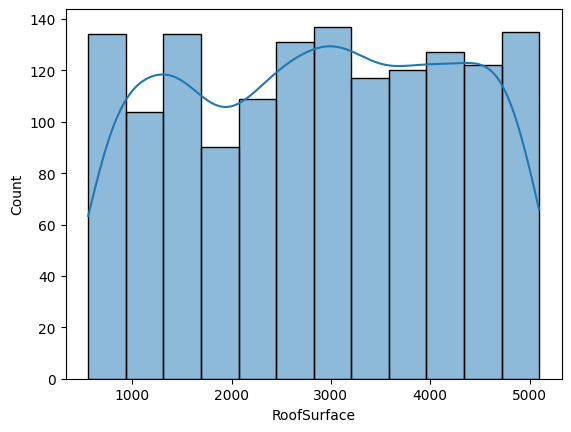

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data["RoofSurface"], kde=True)
plt.show()

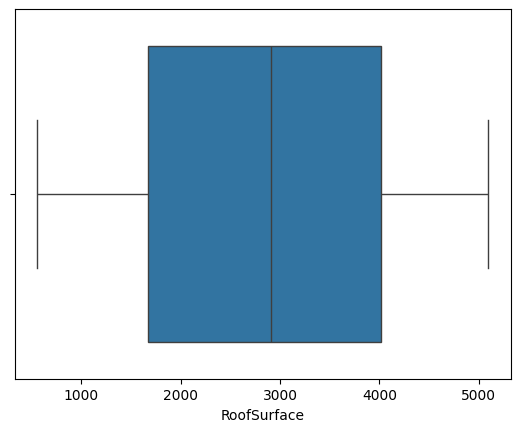

In [14]:
sns.boxplot(x=data["RoofSurface"])
plt.show()

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data["RoofSurface"] = scaler.fit_transform(
    data[["RoofSurface"]]
)

<details>
    <summary>💡 <i>İpucu</i></summary>
    
ℹ️ `RoofSurface` ne Gaussian dağılıma sahip ne de outlier içeriyor $\rightarrow$ MinMaxScaler.
</details>

### `GrLivArea`

❓ `GrLivArea` hakkında **Soru** ❓

👇 `GrLivArea` dağılımını ve outlier'ları incele. Sonra en uygun ölçekleme tekniğini seç. Seçenekler:

1. Standard Scaler
2. Robust Scaler
3. MinMax Scaler

Orijinal sütunu dönüştürülmüş değerlerle değiştir.

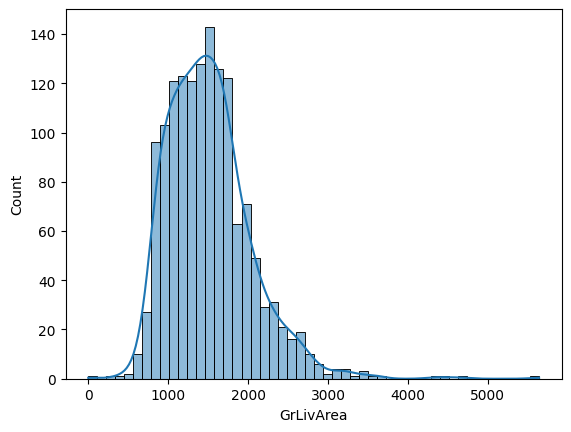

In [16]:
sns.histplot(data["GrLivArea"], kde=True)
plt.show()

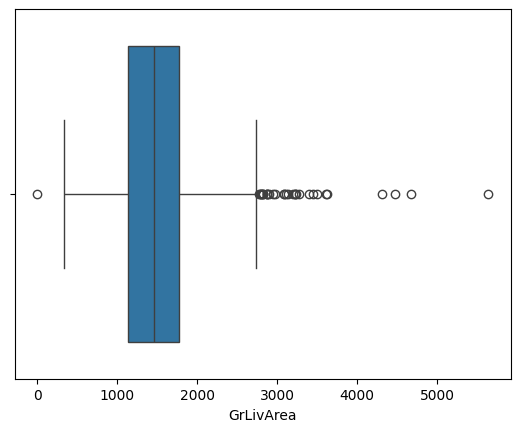

In [17]:
sns.boxplot(x=data["GrLivArea"])
plt.show()

In [18]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

data["GrLivArea"] = scaler.fit_transform(
    data[["GrLivArea"]]
)

<details>
    <summary>💡 <i>İpucu</i></summary>
    
ℹ️ `GrLivArea` çok sayıda outlier içeriyor $\rightarrow$ RobustScaler()
</details>

### `BedroomAbvGr` ,  `OverallCond` & `KitchenAbvGr`

❓ `BedroomAbvGr`, `OverallCond` ve `KitchenAbvGr` hakkında **Sorular** ❓

👇 `BedroomAbvGr`, `OverallCond` ve `KitchenAbvGr` özelliklerini incele. Sonra aşağıdaki ölçekleme tekniklerinden birini seç:

1. MinMax Scaler
2. Standard Scaler
3. Robust Scaler

Orijinal sütunları dönüştürülmüş değerlerle değiştir.

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ["BedroomAbvGr", "OverallCond", "KitchenAbvGr"]

data[cols] = scaler.fit_transform(data[cols])

<details>
    <summary>💡 <i>İpucu</i></summary>
    
ℹ️ `BedroomAbvGr`, `OverallCond` ve `KitchenAbvGr` ordinal özelliklerdir. Outlier oranı %0.1'den az olduğu için _RobustScaler()_ kullanmaya gerek yok. Dağılım Gaussian olmadığı için _StandardScaler()_ da uygun değil. Eleme yöntemiyle güvenle _MinMaxScaler()_ seçebilirsin.
</details>

In [20]:
data.describe()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,RoofSurface,MoSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,0.078410,0.358305,0.348858,0.571918,0.508148,6.321918,180921.195890
std,0.813952,0.101972,0.073446,0.139100,0.291583,2.703626,79442.502883
min,-2.263422,0.000000,0.000000,0.000000,0.000000,1.000000,34900.000000
25%,-0.516802,0.250000,0.333333,0.500000,0.246143,5.000000,129975.000000
50%,0.000000,0.375000,0.333333,0.500000,0.517523,6.000000,163000.000000
75%,0.483198,0.375000,0.333333,0.625000,0.761406,8.000000,214000.000000
max,6.455002,1.000000,1.000000,1.000000,1.000000,12.000000,755000.000000


In [21]:
data

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,RoofSurface,GarageFinish,CentralAir,MoSold,SalePrice
0,0.380070,0.375,0.333333,0.500,0.316729,RFn,Y,2,208500
1,-0.312090,0.375,0.333333,0.875,0.069650,RFn,Y,5,181500
2,0.497489,0.375,0.333333,0.500,0.228124,RFn,Y,9,223500
3,0.390885,0.375,0.333333,0.500,0.442583,Unf,Y,2,140000
4,1.134029,0.500,0.333333,0.500,0.566894,RFn,Y,12,250000
...,...,...,...,...,...,...,...,...,...
1455,0.282735,0.375,0.333333,0.500,0.251267,RFn,Y,8,175000
1456,0.940904,0.375,0.333333,0.625,0.459996,Unf,Y,2,210000
1457,1.353418,0.500,0.333333,1.000,0.036147,RFn,Y,5,266500
1458,-0.596369,0.250,0.333333,0.625,0.648667,Unf,Y,4,142125


🧪 **Kodunu test et**

In [22]:
from nbresult import ChallengeResult

result = ChallengeResult('scaling',
                         dataset=data
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/data-science-preprocessing-workflow/tests
plugins: dash-4.0.0, anyio-4.8.0, langsmith-0.7.23, typeguard-4.4.2
collecting ... collected 3 items

test_scaling.py::TestScaling::test_bedroom_kitchen_condition PASSED      [ 33%]
test_scaling.py::TestScaling::test_gr_liv_area PASSED                    [ 66%]
test_scaling.py::TestScaling::test_roof_surface PASSED                   [100%]

============================== 3 passed in 0.47s ===============================


💯 You can commit your code:

git add tests/scaling.pickle

git commit -m 'Completed scaling step'

git push origin master



## (4) Özellik Kodlama

### `GarageFinish`

❓ `GarageFinish` hakkında **Soru** ❓

👇 `GarageFinish` değerlerini incele ve buna göre aşağıdaki encoding tekniklerinden birini seç:
- Ordinal encoding
- One-Hot encoding

Encoding sonucunu yeni sütun(lar) olarak DataFrame'e ekle ve orijinal sütunu kaldır.


<details>
    <summary>💡 <i>İpucu</i></summary>
        
ℹ️ `GarageFinish` çok kategorili (multicategorical) bir özelliktir ve One-hot-encoded edilmelidir. Ordinal Encoding de düşünülebilir; ancak "Unfinished" veya "no garage" durumlarının "rough finished" durumundan kesinlikle daha kötü olduğunu bilmemiz gerekir!
</details>

In [24]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

encoded = encoder.fit_transform(data[["GarageFinish"]])

In [25]:
encoder.get_feature_names_out()

array(['GarageFinish_Fin', 'GarageFinish_NoGarage', 'GarageFinish_RFn',
       'GarageFinish_Unf'], dtype=object)

In [27]:
import pandas as pd

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["GarageFinish"]),
    index=data.index
)

data = pd.concat([data.drop(columns=["GarageFinish"]), encoded_df], axis=1)

### `CentralAir` Kodlama

❓ `CentralAir` hakkında **Soru** ❓

`CentralAir` değerlerini incele ve buna göre aşağıdaki encoding tekniklerinden birini seç:
- Ordinal encoding
- One-Hot encoding

Orijinal sütunu, yeni oluşturulan encode edilmiş sütun(lar) ile değiştir.


<details>
    <summary>💡 <i>İpucu</i></summary>
    
ℹ️ `CentralAir` ikili (binary) kategorik bir özelliktir.
</details>

In [26]:
data["CentralAir"] = data["CentralAir"].map({"N": 0, "Y": 1})

## (5) Özellik Mühendisliği

### `MoSold` - Döngüsel (Cyclical) mühendislik

👨🏻‍🏫 Bir özellik sayısal (sürekli ya da kesikli), kategorik veya ordinal olabilir. Ama bir özellik zamansal da olabilir (örn. çeyrekler, aylar, günler, dakikalar, ...).

Zaman gibi döngüsel özellikler özel bir ön işleme gerektirir. Çünkü herhangi bir Machine Learning algoritmasının bu döngüselliği yakalayabilmesi için, döngüsel özelliklerin belirli bir şekilde ön işlenmesi gerekir.

👉 `MoSold` özelliğini düşün: evin satıldığı ay.

In [28]:
data["MoSold"].value_counts()

MoSold
6     253
7     234
5     204
4     141
8     122
3     106
10     89
11     79
9      63
12     59
1      58
2      52
Name: count, dtype: int64

* Birçok ev Haziran (6), Temmuz (7) ve Mayıs (5) aylarında satılmış (İlkbahar/Yaz)
* Aralık (12), Ocak (1) ve Şubat (2) aylarında ise çok az ev satılmış (~ Sonbahar/Kış)
    * Ancak herhangi bir Machine Learning modeli için Aralık (12) ile Ocak (1) aylarının "yakın" olması için bir neden yok...

👩🏻‍🏫 ***Döngüsel özelliklerle nasıl başa çıkılır?***

1. Aşağıdaki görsele bak ve iki farklı ayı ayırt etmek için açıklamaları oku.

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/cyclical_feature_engineering.png" alt="Cyclical features" width="1000">


2. Daha fazla detay için bu [makaleyi](https://ianlondon.github.io/posts/encoding-cyclical-features-24-hour-time/) oku.




❓ `MoSold` hakkında **Soru** ❓ 
- Sırasıyla MoSold'un sinüs ve kosinüsünü temsil eden `sin_MoSold` ve `cos_MoSold` adında iki yeni özellik oluştur.
- Orijinal `MoSold` sütununu sil

<details>
    <summary>💡 <i>İpucu</i></summary>
    
Gün içindeki saniyeyi veren bir sütundan zamansal özellik üretmek için!
```python
seconds_in_day = 24*60*60

df['sin_time'] = np.sin(2*np.pi*df.seconds/seconds_in_day)
df['cos_time'] = np.cos(2*np.pi*df.seconds/seconds_in_day)
df.drop(columns=['seconds'], inplace=True)

df.head()
```


</details>

In [29]:
data["sin_MoSold"] = np.sin(2 * np.pi * data["MoSold"] / 12)
data["cos_MoSold"] = np.cos(2 * np.pi * data["MoSold"] / 12)

data = data.drop(columns=["MoSold"])

🧪 **Kodunu test et**

In [30]:
from nbresult import ChallengeResult

result = ChallengeResult('encoding', dataset=data, new_features=['sin_MoSold', 'cos_MoSold'])

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/data-science-preprocessing-workflow/tests
plugins: dash-4.0.0, anyio-4.8.0, langsmith-0.7.23, typeguard-4.4.2
collecting ... collected 4 items

test_encoding.py::TestEncoding::test_central_air PASSED                  [ 25%]
test_encoding.py::TestEncoding::test_columns PASSED                      [ 50%]
test_encoding.py::TestEncoding::test_month_sold_features PASSED          [ 75%]
test_encoding.py::TestEncoding::test_month_sold_features_number PASSED   [100%]

============================== 4 passed in 0.46s ===============================


💯 You can commit your code:

git add tests/encoding.pickle

git commit -m 'Completed encoding step'

git push origin master



## (6) Ön işlenmiş veri kümesini dışa aktar

👇 Veri kümesi ön işlendiğine göre, dışa aktarmak için aşağıdaki kodu çalıştır. Sonraki alıştırmada bununla çalışmaya devam edeceksin.

In [ ]:
data.to_csv("data/clean_dataset.csv", index=False)

🏁 Tebrikler! Artık bir veri kümesini ***nasıl ön işleyeceğini*** biliyorsun!

💾 Notebook'unu git add/commit/push yapmayı unutma...

